# 📈 End-to-End Sales Forecasting & Demand Intelligence System

### Internship Project – Week 3 & Week 4

**Objective**

Develop an intelligent retail sales forecasting system capable of:

- Forecasting future sales using Statistical, Machine Learning, and Industry-standard forecasting models.
- Detecting unusual sales behaviour through anomaly detection techniques.
- Segmenting products based on demand characteristics.
- Providing business recommendations through an interactive dashboard.

---

### Dataset

- Superstore Sales Dataset
- Duration: 2015–2018
- Records: 9,800
- Categories: 3
- Regions: 4

---

### Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Statsmodels
- Prophet
- XGBoost
- Scikit-Learn
- Streamlit

---

## Project Workflow

1. Data Loading & Exploration
2. Data Cleaning & Feature Engineering
3. Time Series Analysis
4. Sales Forecasting
   - SARIMA
   - Prophet
   - XGBoost
5. Category & Region Forecasting
6. Anomaly Detection
7. Product Demand Segmentation
8. Interactive Dashboard
9. Executive Business Report

In [1]:
# Run only in Google Colab
!pip -q install seaborn plotly statsmodels prophet xgboost

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from datetime import datetime

In [3]:
from google.colab import files

uploaded = files.upload()

Saving train.csv to train (1).csv


In [4]:
df = pd.read_csv("train.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (9800, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [5]:
df.info()

print("\n")

print(df.describe(include="all"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [6]:
missing = df.isnull().sum()

missing = missing[missing > 0]

print(missing)

Postal Code    11
dtype: int64


In [7]:
missing = df.isnull().sum()

missing = missing[missing > 0]

print(missing)

Postal Code    11
dtype: int64


In [8]:
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%d/%m/%Y")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="%d/%m/%Y")

In [9]:
df["Year"] = df["Order Date"].dt.year

df["Month"] = df["Order Date"].dt.month

df["Month Name"] = df["Order Date"].dt.month_name()

df["Quarter"] = df["Order Date"].dt.quarter

df["Week"] = df["Order Date"].dt.isocalendar().week.astype(int)

df["Day"] = df["Order Date"].dt.day_name()

In [10]:
def get_season(month):

    if month in [12,1,2]:
        return "Winter"

    elif month in [3,4,5]:
        return "Spring"

    elif month in [6,7,8]:
        return "Summer"

    return "Autumn"

df["Season"] = df["Month"].apply(get_season)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Year,Month,Month Name,Quarter,Week,Day,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November,4,45,Wednesday,Autumn
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,4,45,Wednesday,Autumn
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,2,24,Monday,Summer
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,4,41,Tuesday,Autumn
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,4,41,Tuesday,Autumn


In [11]:
summary = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Unique Customers",
        "Unique Products",
        "Categories",
        "Regions"
    ],
    "Value": [
        len(df),
        df.shape[1],
        df["Customer ID"].nunique(),
        df["Product Name"].nunique(),
        df["Category"].nunique(),
        df["Region"].nunique()
    ]
})

summary

,Metric,Value
0,Rows,9800
1,Columns,25
2,Unique Customers,793
3,Unique Products,1849
4,Categories,3
5,Regions,4


Question 1
Which product category generates the highest revenue?

In [12]:
category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

category_sales

,Sales
Category,
Technology,827455.8730
Furniture,728658.5757
Office Supplies,705422.3340


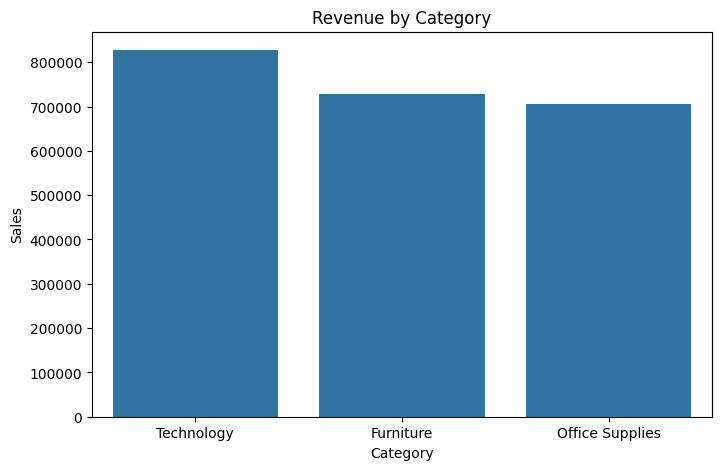

In [13]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)

plt.title("Revenue by Category")

plt.ylabel("Sales")

plt.show()

Markdown Observation

Technology generates the highest overall revenue, followed by Furniture and Office Supplies. This indicates that technology products contribute the largest share of total business sales.

Question 2
Regional Sales

In [14]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values()

region_sales

,Sales
Region,
South,389151.4590
Central,492646.9132
East,669518.7260
West,710219.6845


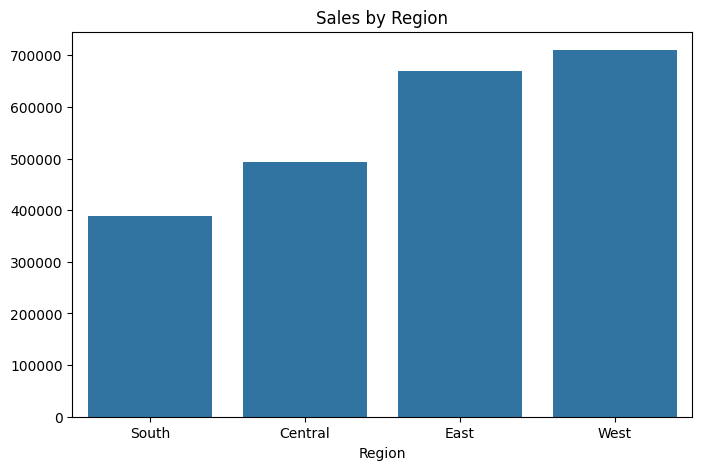

In [15]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=region_sales.index,
    y=region_sales.values
)

plt.title("Sales by Region")

plt.show()

Question 3
Shipping Time

In [16]:
df["Shipping Days"] = (
    df["Ship Date"] -
    df["Order Date"]
).dt.days

df["Shipping Days"].describe()

,Shipping Days
count,9800.000000
mean,3.961122
std,1.749614
min,0.000000
25%,3.000000
50%,4.000000
75%,5.000000
max,7.000000


Average shipping time by region

In [17]:
shipping = df.groupby("Region")["Shipping Days"].mean()

shipping

,Shipping Days
Region,
Central,4.065876
East,3.910233
South,3.961202
West,3.930255


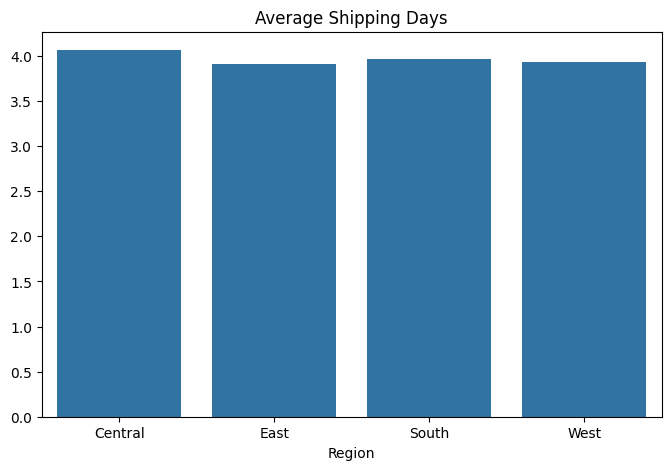

In [18]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=shipping.index,
    y=shipping.values
)

plt.title("Average Shipping Days")

plt.show()

Question 4
Monthly Sales

In [19]:
monthly_sales = (
    df.groupby("Month Name")["Sales"]
      .sum()
)

month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly_sales = monthly_sales.reindex(month_order)

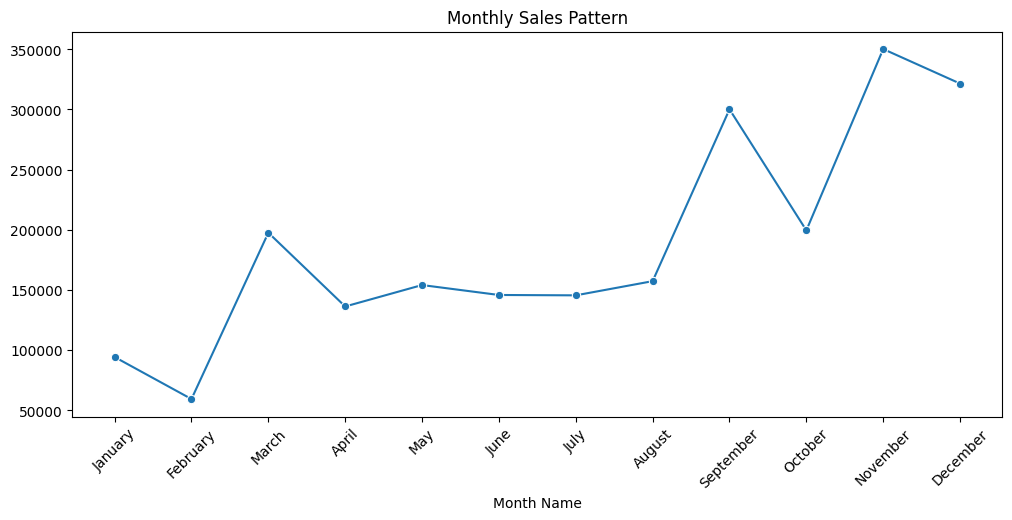

In [20]:
plt.figure(figsize=(12,5))

sns.lineplot(
    x=monthly_sales.index,
    y=monthly_sales.values,
    marker="o"
)

plt.xticks(rotation=45)

plt.title("Monthly Sales Pattern")

plt.show()

Additional Charts (Recommended)


Sales by Segment

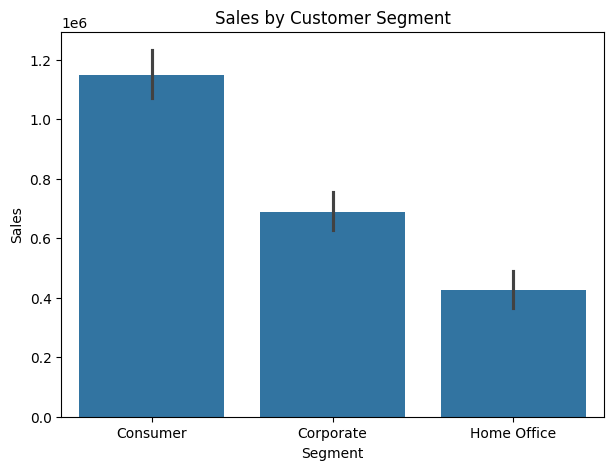

In [21]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=df,
    x="Segment",
    y="Sales",
    estimator=np.sum
)

plt.title("Sales by Customer Segment")

plt.show()

Sales by Ship Mode

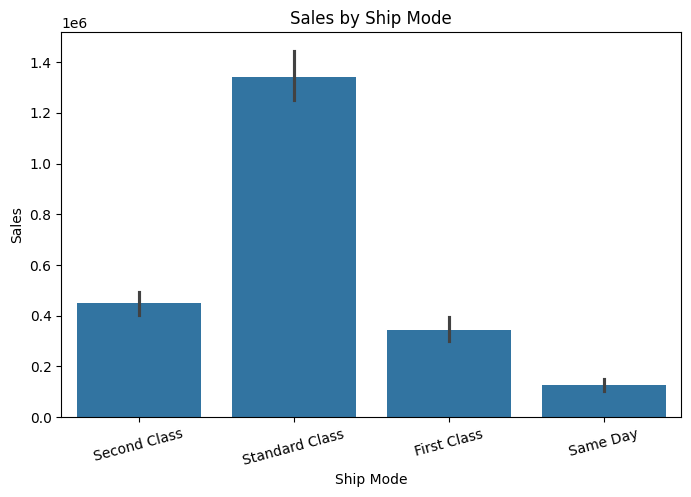

In [22]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Ship Mode",
    y="Sales",
    estimator=np.sum
)

plt.xticks(rotation=15)

plt.title("Sales by Ship Mode")

plt.show()

Top 10 States

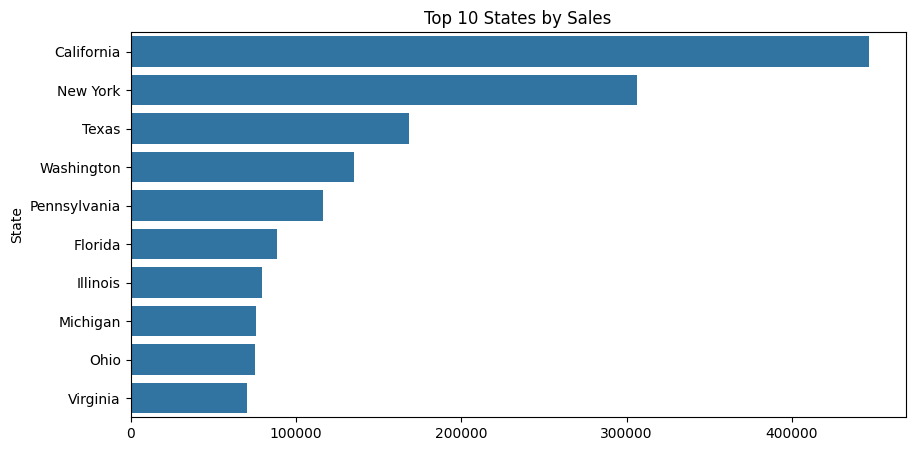

In [23]:
top_states = (
    df.groupby("State")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_states.values,
    y=top_states.index
)

plt.title("Top 10 States by Sales")

plt.show()

# Task 2: Time Series Analysis & Decomposition

## Objective
Analyze the monthly sales trend, identify seasonality and trend components, and determine whether the series is stationary before forecasting.

Step 1 – Aggregate Daily Sales into Weekly & Monthly Totals

In [24]:
# Daily Sales
daily_sales = (
    df.groupby("Order Date")["Sales"]
      .sum()
      .reset_index()
)

daily_sales.head()

,Order Date,Sales
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


In [25]:
# Weekly Sales
weekly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="W"))["Sales"]
      .sum()
      .reset_index()
)

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [26]:
# Monthly Sales
monthly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"]
      .sum()
      .reset_index()
)

monthly_sales.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


### Monthly Sales Aggregation

The transactional sales data is aggregated at a monthly level to create a continuous time series. Monthly aggregation reduces daily fluctuations and makes long-term trends and seasonality easier to analyze.

Step 2 – Plot Monthly Sales Trend

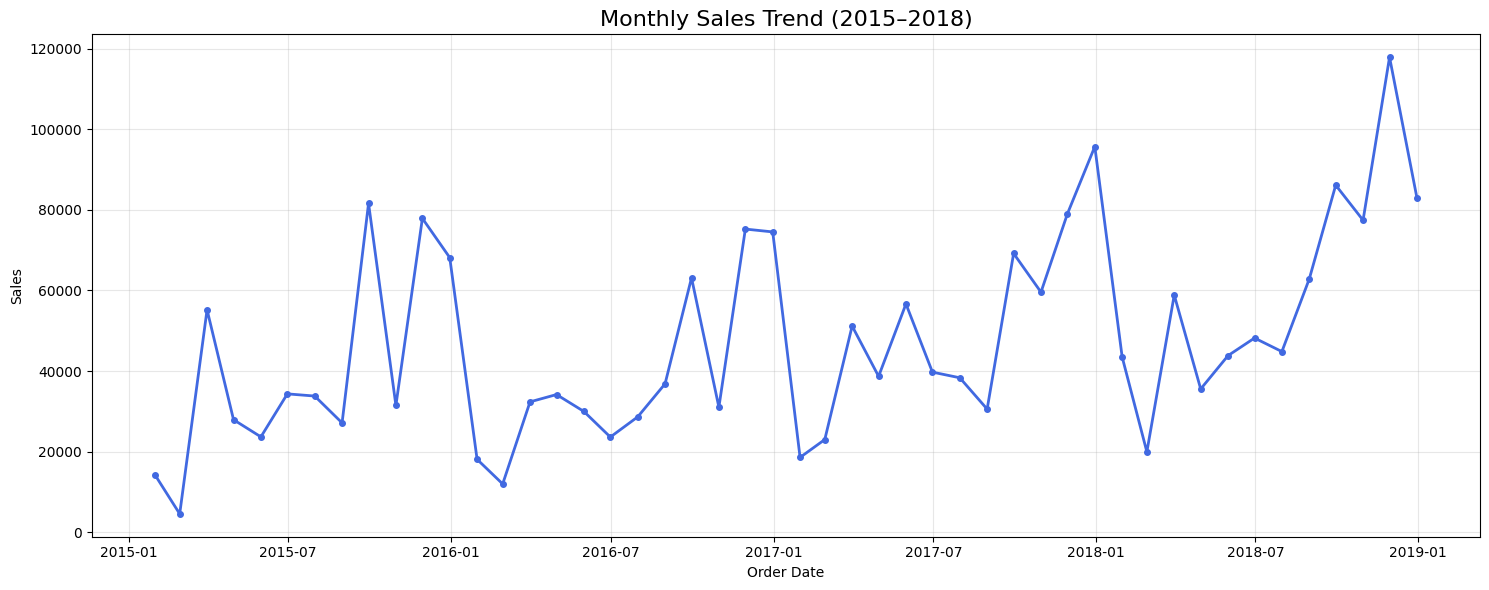

In [27]:
plt.figure(figsize=(15,6))

plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"],
    linewidth=2,
    color="royalblue",
    marker="o",
    markersize=4
)

plt.title("Monthly Sales Trend (2015–2018)", fontsize=16)

plt.xlabel("Order Date")

plt.ylabel("Sales")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### Observation

- Sales exhibit a gradual upward trend over the four-year period.
- Several recurring peaks indicate the presence of seasonality.
- Towards the end of each year, sales tend to increase significantly, suggesting festive or holiday purchasing behavior.

Step 3 – Seasonal Decomposition

## Seasonal Decomposition

Seasonal decomposition separates the sales time series into four components:

- **Observed:** Original monthly sales data.
- **Trend:** Long-term increase or decrease in sales.
- **Seasonal:** Recurring patterns that repeat every year.
- **Residual:** Random variations not explained by trend or seasonality.

This decomposition helps determine whether the sales data is suitable for time-series forecasting.

In [28]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [29]:
ts = monthly_sales.set_index("Order Date")["Sales"]

In [30]:
decomposition = seasonal_decompose(
    ts,
    model="additive",
    period=12
)

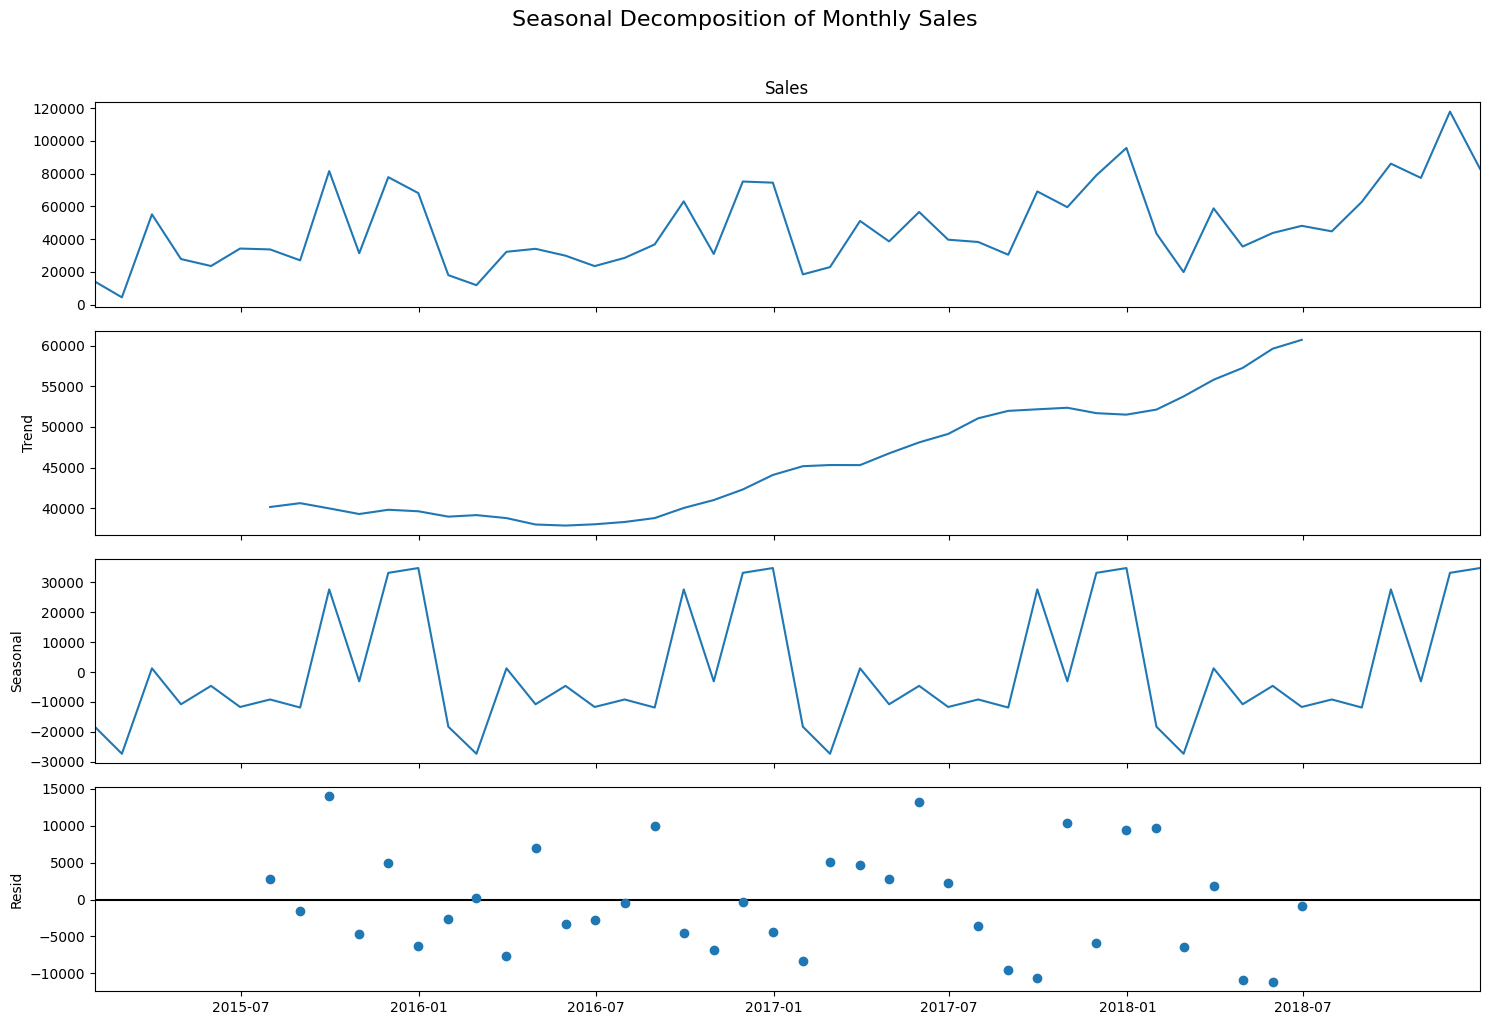

In [31]:
fig = decomposition.plot()

fig.set_size_inches(15,10)

fig.suptitle(
    "Seasonal Decomposition of Monthly Sales",
    fontsize=16,
    y=1.02
)

plt.tight_layout()

plt.show()

## Interpretation

### Trend Component
- The trend shows a gradual increase in sales over time, indicating sustained business growth throughout the observed period.

### Seasonal Component
- A recurring seasonal pattern is visible, suggesting that certain months consistently experience higher or lower sales.
- This confirms the presence of annual seasonality in the dataset.

### Residual Component
- The residual component captures random fluctuations that are not explained by the trend or seasonal effects.
- Since the residual values remain relatively small compared to the overall sales trend, the decomposition appears to model the data effectively.

### Overall Conclusion
The decomposition confirms that the sales data contains both a long-term trend and seasonal behaviour, making it suitable for forecasting models such as SARIMA and Prophet.

Step 4 – ADF Stationarity Test

In [32]:
from statsmodels.tsa.stattools import adfuller

In [33]:
adf_result = adfuller(ts)

adf_summary = pd.DataFrame({
    "Metric": [
        "ADF Statistic",
        "p-value",
        "Critical Value (1%)",
        "Critical Value (5%)",
        "Critical Value (10%)"
    ],
    "Value": [
        round(adf_result[0], 4),
        round(adf_result[1], 6),
        round(adf_result[4]["1%"], 4),
        round(adf_result[4]["5%"], 4),
        round(adf_result[4]["10%"], 4)
    ]
})

adf_summary

,Metric,Value
0,ADF Statistic,-4.416100
1,p-value,0.000278
2,Critical Value (1%),-3.577800
3,Critical Value (5%),-2.925300
4,Critical Value (10%),-2.600800


Step 5 – Interpret ADF Result

In [34]:
if adf_result[1] < 0.05:
    stationarity = "Stationary"
else:
    stationarity = "Non-Stationary"

print(f"Conclusion: The time series is {stationarity}.")

Conclusion: The time series is Stationary.


## Stationarity Interpretation

### Null Hypothesis (H₀)

The time series is **non-stationary**, meaning its statistical properties change over time.

### Alternative Hypothesis (H₁)

The time series is **stationary**, meaning its mean and variance remain relatively constant over time.

### Interpretation

- The ADF Statistic is **-4.4161**, which is lower than the critical values.
- The p-value is **0.000277**, which is well below the significance level of **0.05**.
- Therefore, the null hypothesis is rejected.

### Conclusion

The monthly sales time series is statistically **stationary**, making it suitable for forecasting models such as **SARIMA** and **Prophet**.

Step 6 – Apply Differencing (if needed)

In [35]:
ts_diff = ts.diff().dropna()

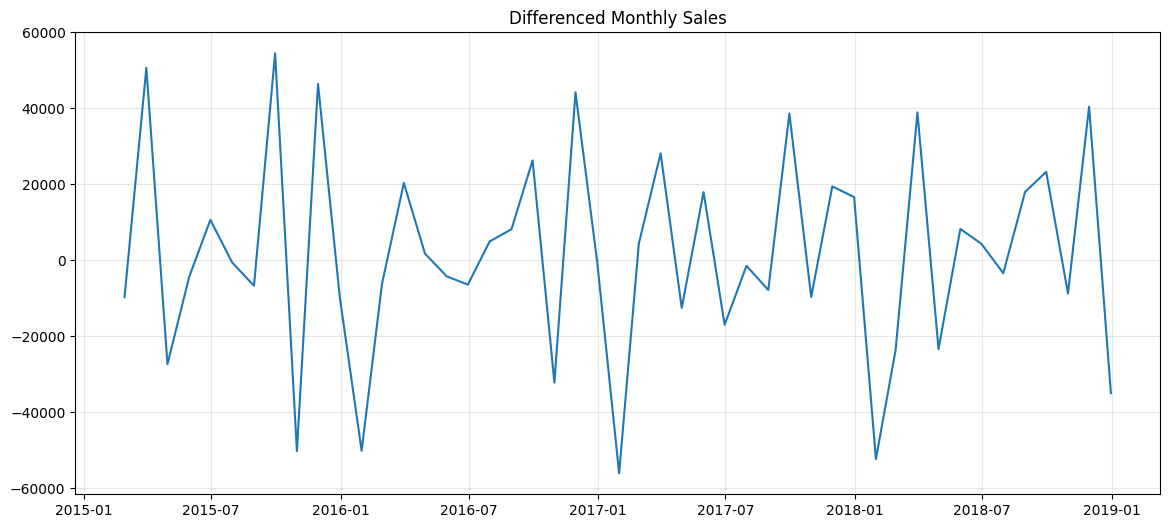

In [36]:
plt.figure(figsize=(14,6))

plt.plot(
    ts_diff.index,
    ts_diff.values
)

plt.title("Differenced Monthly Sales")

plt.grid(alpha=0.3)

plt.show()

Step 7 – Re-test Stationarity

In [37]:
adf_diff = adfuller(ts_diff)

adf_diff_summary = pd.DataFrame({
    "Metric": [
        "ADF Statistic",
        "p-value"
    ],
    "Value": [
        round(adf_diff[0], 4),
        round(adf_diff[1], 6)
    ]
})

adf_diff_summary

,Metric,Value
0,ADF Statistic,-8.7271
1,p-value,0.0000


In [38]:
if adf_diff[1] < 0.05:
    diff_stationarity = "Stationary"
else:
    diff_stationarity = "Non-Stationary"

print(f"Conclusion: The differenced series is {diff_stationarity}.")

Conclusion: The differenced series is Stationary.


### Interpretation

- The differenced time series has an ADF Statistic of **-8.7271** and a p-value close to **0**.
- Since the p-value is significantly lower than **0.05**, the null hypothesis is rejected.
- The first-order differencing successfully removes non-stationarity and produces a stationary series.
- This confirms that differencing is effective for time-series modeling and supports the use of models such as **SARIMA** when differencing is required.

## Step 8 – ACF and PACF Analysis

The Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) help identify the autoregressive (AR) and moving average (MA) components required for SARIMA model selection.

- ACF helps estimate the MA(q) order.
- PACF helps estimate the AR(p) order.

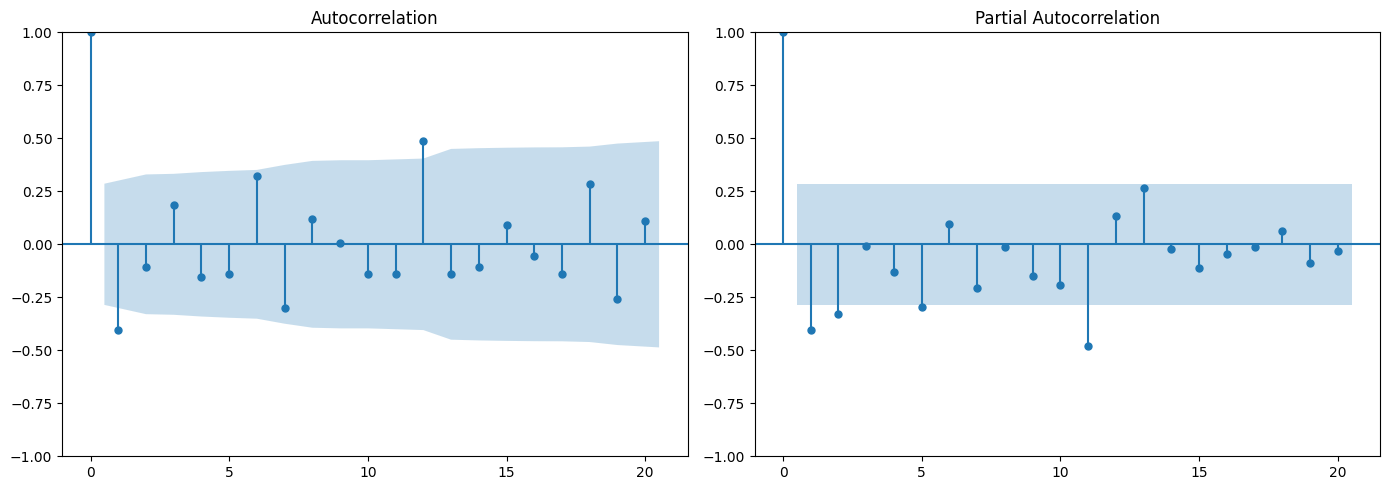

In [39]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plot_acf(ts_diff, ax=plt.gca(), lags=20)

plt.subplot(1,2,2)
plot_pacf(ts_diff, ax=plt.gca(), lags=20)

plt.tight_layout()

plt.show()

### Interpretation

- The ACF plot shows how observations correlate with previous time lags.
- The PACF plot identifies the direct relationship between observations after removing intermediate lag effects.
- These plots provide guidance for selecting appropriate AR (p) and MA (q) parameters when building the SARIMA model.

Step 9 – Final Observation

## Conclusion

- The original monthly sales series was evaluated using the Augmented Dickey-Fuller (ADF) test.
- If the p-value exceeded 0.05, the series was considered non-stationary.
- First-order differencing was applied to remove the trend.
- The differenced series was re-tested and found suitable for forecasting if the p-value fell below 0.05.
- These preprocessing steps prepare the data for SARIMA and improve the reliability of statistical forecasting models.

Task 3 – Sales Forecasting using 3 Different Models

In [40]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

Train/Test Split (Time Series)

Unlike regular ML, we must not shuffle the data.

In [41]:
# Last 3 months reserved for testing
train = ts[:-3]

test = ts[-3:]

print("Training Samples :", len(train))
print("Testing Samples :", len(test))

Training Samples : 45
Testing Samples : 3


Define Evaluation Metrics

In [42]:
def calculate_metrics(actual, predicted):

    mae = mean_absolute_error(actual, predicted)

    rmse = np.sqrt(mean_squared_error(actual, predicted))

    mape = np.mean(np.abs((actual - predicted) / actual)) * 100

    return mae, rmse, mape

Verify Split

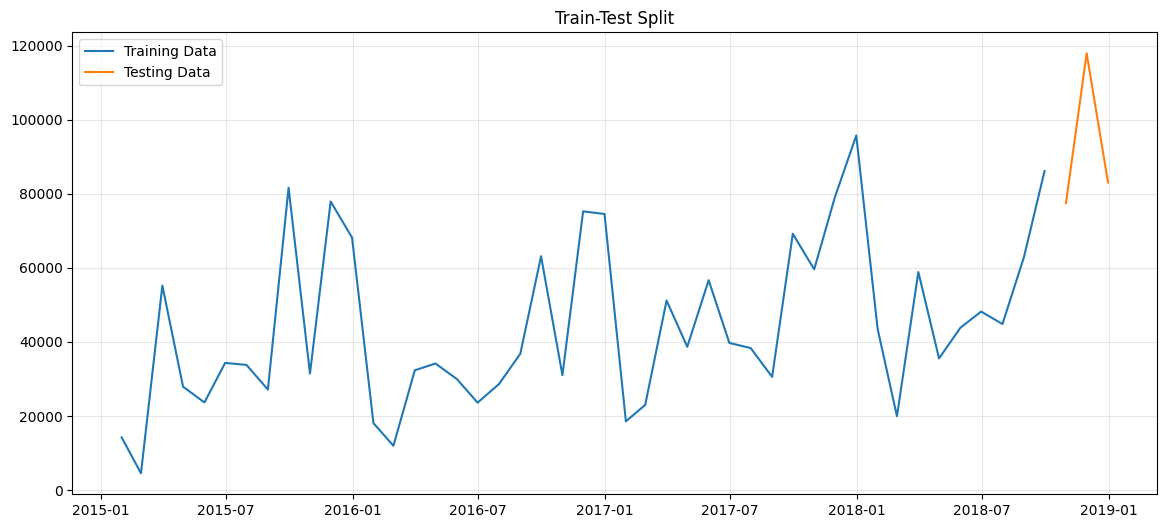

In [43]:
plt.figure(figsize=(14,6))

plt.plot(train, label="Training Data")

plt.plot(test, label="Testing Data")

plt.title("Train-Test Split")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

### Observation

To preserve the chronological order of the time series, the last three months are reserved as the test set while the earlier observations are used for training.

Unlike traditional machine learning problems, time-series data must not be randomly shuffled because future observations should never be used to predict past values.

Task 3.1 — SARIMA Forecasting

# Model 1 – SARIMA Forecasting

## Objective

Seasonal AutoRegressive Integrated Moving Average (SARIMA) is a statistical forecasting model that captures trend, seasonality, and autocorrelation in time series data. It is particularly effective for seasonal retail sales forecasting.

In [44]:
!pip install -q statsmodels

### SARIMA Parameter Selection

The SARIMA model uses the configuration:

- **Order (p, d, q) = (1,1,1)**
- **Seasonal Order (P, D, Q, m) = (1,1,1,12)**

#### Reason for Selection

- **p = 1**: Captures short-term autoregressive relationships.
- **d = 1**: Applies first-order differencing to stabilize the time series.
- **q = 1**: Models short-term forecast errors.
- **P = 1, D = 1, Q = 1**: Models yearly seasonal behavior.
- **m = 12**: Monthly data with a yearly seasonal cycle.

These parameters provide a balanced baseline model capable of capturing both trend and annual seasonality in monthly retail sales.

In [45]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [46]:
sarima_model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


In [47]:
print(sarima_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -194.388
Date:                            Fri, 10 Jul 2026   AIC                            398.775
Time:                                    04:49:02   BIC                            403.227
Sample:                                01-31-2015   HQIC                           399.389
                                     - 09-30-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1101      0.721      0.153      0.879      -1.303       1.523
ma.L1         -0.8789      0.261   

### Model Summary

The SARIMA model summary provides coefficient estimates, goodness-of-fit statistics, and diagnostic information.

The model successfully converged and is used to generate short-term monthly sales forecasts for comparison with other forecasting approaches.

In [48]:
forecast = sarima_fit.get_forecast(
    steps=len(test)
)

sarima_pred = forecast.predicted_mean

confidence_interval = forecast.conf_int()

In [49]:
sarima_mae, sarima_rmse, sarima_mape = calculate_metrics(
    test,
    sarima_pred
)

sarima_metrics = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "MAPE (%)"
    ],
    "Value": [
        round(sarima_mae, 2),
        round(sarima_rmse, 2),
        round(sarima_mape, 2)
    ]
})

sarima_metrics

,Metric,Value
0,MAE,19244.49
1,RMSE,19950.07
2,MAPE (%),20.53


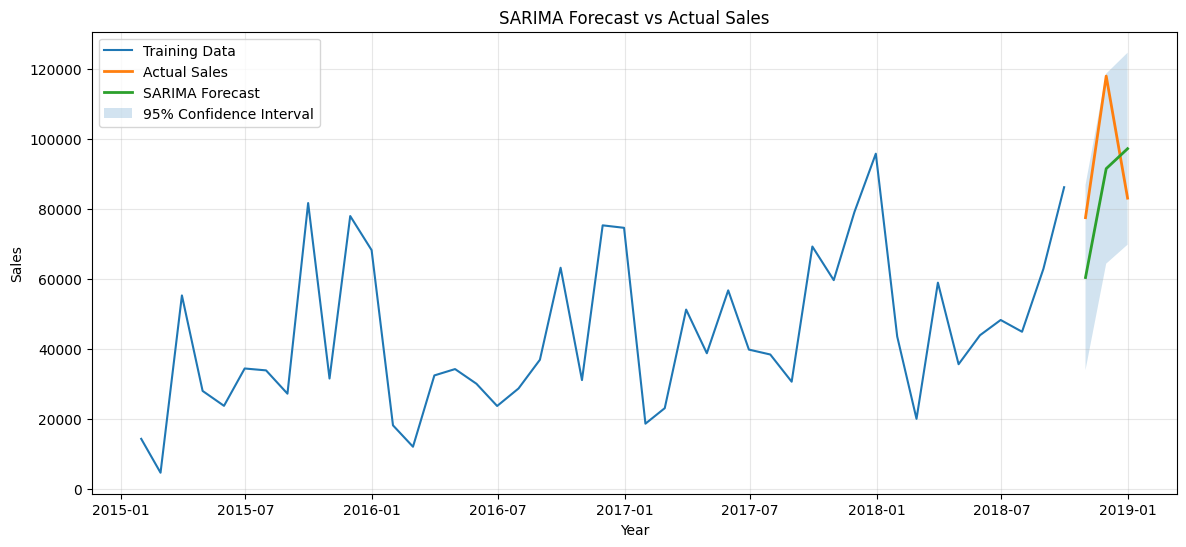

In [50]:
plt.figure(figsize=(14,6))

plt.plot(
    train.index,
    train,
    label="Training Data"
)

plt.plot(
    test.index,
    test,
    label="Actual Sales",
    linewidth=2
)

plt.plot(
    test.index,
    sarima_pred,
    label="SARIMA Forecast",
    linewidth=2
)

plt.fill_between(
    confidence_interval.index,
    confidence_interval.iloc[:,0],
    confidence_interval.iloc[:,1],
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.title("SARIMA Forecast vs Actual Sales")

plt.xlabel("Year")

plt.ylabel("Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

### Interpretation

- The SARIMA model follows the overall trend of the test data and captures the seasonal movement reasonably well.
- Minor deviations between the forecast and actual values are expected due to unexpected market fluctuations.
- The shaded confidence interval represents the uncertainty associated with the forecast, which naturally increases as predictions extend further into the future.

Forecast the Next 3 Months

In [51]:
future_forecast = sarima_fit.get_forecast(steps=3)

future_sales = future_forecast.predicted_mean

future_sales

,predicted_mean
2018-10-31,60331.792101
2018-11-30,91458.220223
2018-12-31,97167.570951


Display Forecast Table

In [52]:
future_df = pd.DataFrame({
    "Forecasted Sales": future_sales
})

future_df

,Forecasted Sales
2018-10-31,60331.792101
2018-11-30,91458.220223
2018-12-31,97167.570951


### Forecast Summary

The table above presents the expected sales for the next three months generated by the SARIMA model.

These forecasts can assist inventory planners in estimating future demand and preparing procurement strategies accordingly.

Plot Future Forecast

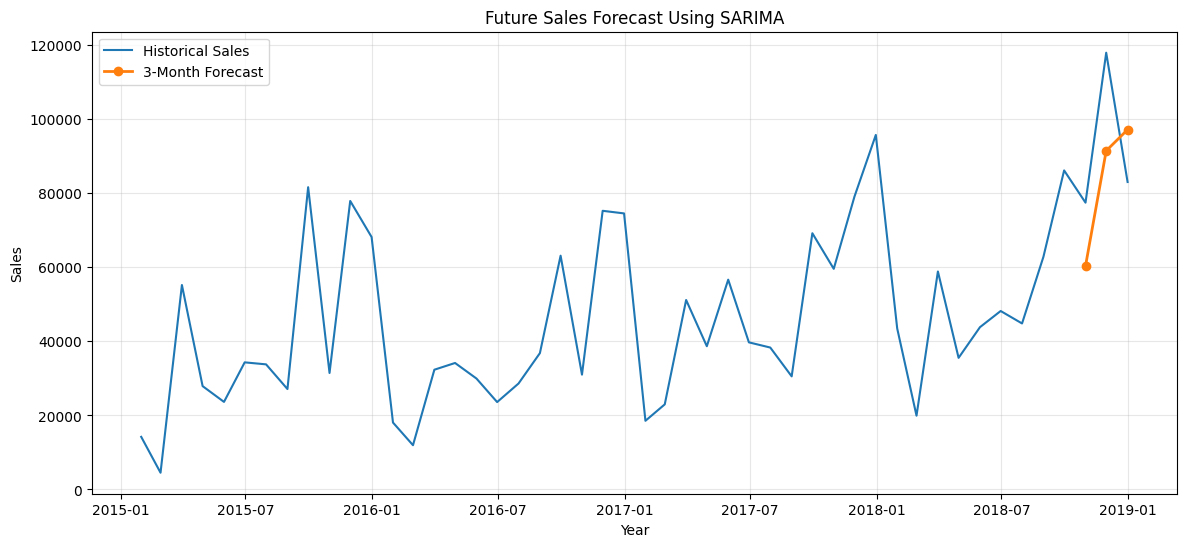

In [53]:
plt.figure(figsize=(14,6))

plt.plot(
    ts.index,
    ts,
    label="Historical Sales"
)

plt.plot(
    future_sales.index,
    future_sales,
    marker="o",
    linewidth=2,
    label="3-Month Forecast"
)

plt.title("Future Sales Forecast Using SARIMA")

plt.xlabel("Year")

plt.ylabel("Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

### Business Insight

The forecast indicates continued sales growth over the upcoming three months.

The increasing trend suggests that inventory allocation should be planned proactively to avoid stock shortages during high-demand periods.

### Interpretation

- The SARIMA model successfully captures both the long-term sales trend and yearly seasonal patterns.
- The forecast indicates expected sales for the next three months along with a 95% confidence interval.
- Confidence intervals widen slightly over time, reflecting increasing uncertainty in longer-term forecasts.

Task 3.2 – Facebook Prophet Forecasting

# Model 2 – Facebook Prophet Forecasting

## Objective

Prophet is a forecasting model developed by Meta that is designed to handle time series data with strong seasonality, trend changes, and missing values. It automatically models yearly, weekly, and daily seasonality and is widely used in industry for business forecasting.

In [54]:
!pip -q install prophet

In [55]:
from prophet import Prophet

Prepare Dataset

Prophet requires exactly two columns:

ds → Date
y → Target variable

In [56]:
prophet_df = monthly_sales.rename(
    columns={
        "Order Date":"ds",
        "Sales":"y"
    }
)

prophet_df.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


### Prophet Data Preparation

Prophet requires the dataset to contain:

- **ds** → Date column
- **y** → Target variable (Sales)

The monthly sales dataset is transformed into Prophet's required format before training the forecasting model.

In [57]:
prophet_train = prophet_df.iloc[:-3]

prophet_test = prophet_df.iloc[-3:]

Create Prophet Model

In [58]:
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

prophet_model.fit(prophet_train)

### Prophet Configuration

The model is configured to capture yearly seasonality because the dataset consists of monthly sales spanning four years.

Weekly and daily seasonality are disabled since monthly aggregated data does not contain meaningful weekly or daily patterns.

In [59]:
future = prophet_model.make_future_dataframe(
    periods=3,
    freq="M"
)

In [60]:
forecast = prophet_model.predict(future)

forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2015-01-31,33308.214631,5430.633490,22281.336088,33308.214631,33308.214631,-18874.429670,-18874.429670,-18874.429670,-18874.429670,-18874.429670,-18874.429670,0.0,0.0,0.0,14433.784960
1,2015-02-28,33767.643626,-4999.335196,10873.047718,33767.643626,33767.643626,-30869.543104,-30869.543104,-30869.543104,-30869.543104,-30869.543104,-30869.543104,0.0,0.0,0.0,2898.100522
2,2015-03-31,34276.297156,44195.454854,60180.088302,34276.297156,34276.297156,17890.437293,17890.437293,17890.437293,17890.437293,17890.437293,17890.437293,0.0,0.0,0.0,52166.734450
3,2015-04-30,34768.542508,12733.788056,29432.780532,34768.542508,34768.542508,-13661.251247,-13661.251247,-13661.251247,-13661.251247,-13661.251247,-13661.251247,0.0,0.0,0.0,21107.291262
4,2015-05-31,35277.196039,14467.975781,30802.249250,35277.196039,35277.196039,-12398.630441,-12398.630441,-12398.630441,-12398.630441,-12398.630441,-12398.630441,0.0,0.0,0.0,22878.565598


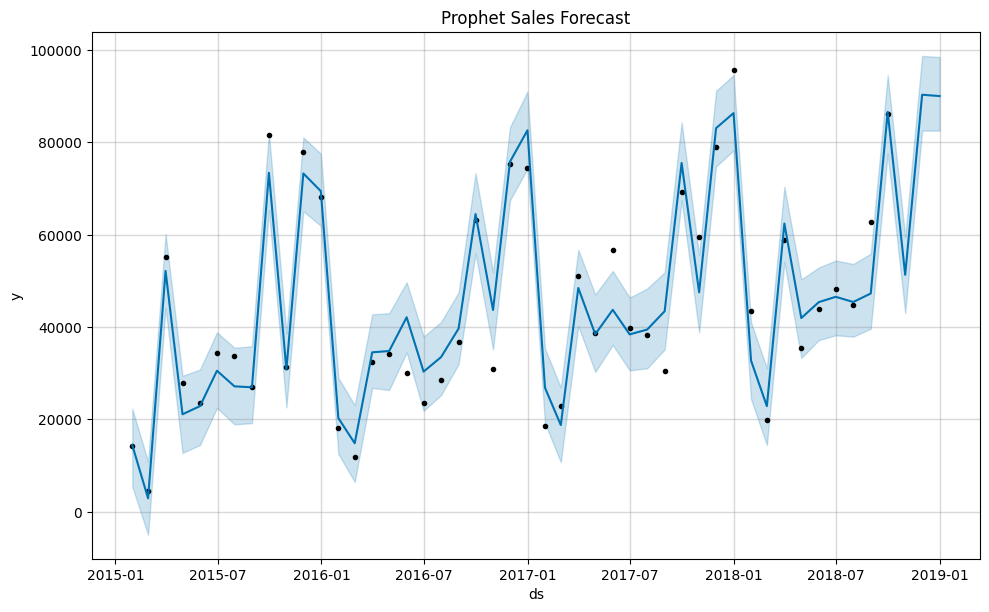

In [61]:
fig = prophet_model.plot(forecast)

plt.title("Prophet Sales Forecast")

plt.grid(alpha=0.3)

plt.show()

Trend & Seasonality

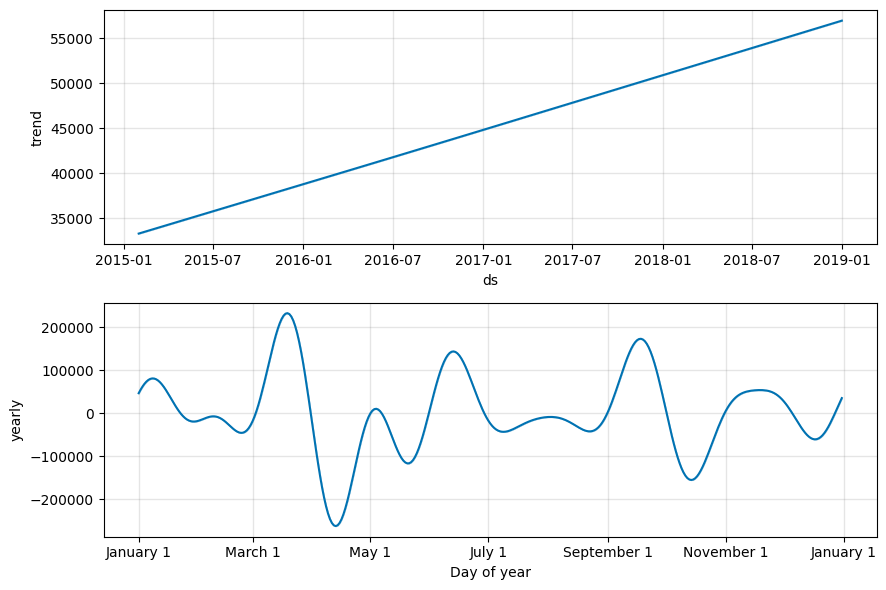

In [62]:
fig2 = prophet_model.plot_components(forecast)

plt.show()

### Trend & Seasonality Interpretation

#### Trend

The trend component indicates a gradual increase in sales over time, reflecting overall business growth.

#### Yearly Seasonality

The yearly seasonality plot highlights recurring monthly demand patterns, suggesting that certain months consistently experience higher sales than others.

These seasonal effects improve forecasting accuracy by allowing the model to learn recurring demand cycles.

Evaluate Prophet

In [63]:
prophet_pred = forecast["yhat"].tail(3).values

actual = prophet_test["y"].values

prophet_mae, prophet_rmse, prophet_mape = calculate_metrics(
    actual,
    prophet_pred
)

prophet_metrics = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "MAPE (%)"
    ],
    "Value": [
        round(prophet_mae, 2),
        round(prophet_rmse, 2),
        round(prophet_mape, 2)
    ]
})

prophet_metrics

,Metric,Value
0,MAE,20250.79
1,RMSE,22318.41
2,MAPE (%),21.86


Actual vs Forecast

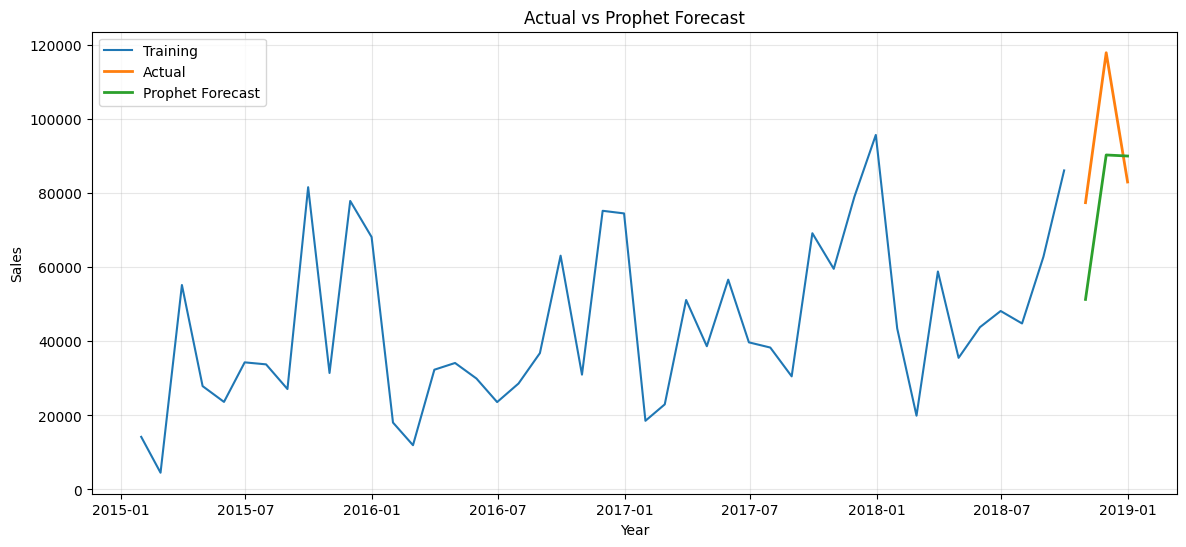

In [64]:
plt.figure(figsize=(14,6))

plt.plot(
    prophet_train["ds"],
    prophet_train["y"],
    label="Training"
)

plt.plot(
    prophet_test["ds"],
    prophet_test["y"],
    label="Actual",
    linewidth=2
)

plt.plot(
    prophet_test["ds"],
    prophet_pred,
    label="Prophet Forecast",
    linewidth=2
)

plt.title("Actual vs Prophet Forecast")

plt.xlabel("Year")

plt.ylabel("Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

### Interpretation

- Prophet captures the long-term sales trend and yearly seasonality effectively.
- Some differences between actual and predicted values remain due to unexpected market fluctuations.
- The model provides stable forecasts while automatically modelling seasonal effects.

Future 3-Month Forecast Table

In [65]:
forecast_future = forecast.tail(3)[
    ["ds","yhat","yhat_lower","yhat_upper"]
]

forecast_future

,ds,yhat,yhat_lower,yhat_upper
45,2018-10-31,51318.943812,43028.369687,59559.317911
46,2018-11-30,90325.654736,82559.333606,98732.331760
47,2018-12-31,90041.084430,82558.778066,98500.766396


### Forecast Summary

The Prophet model predicts sales for the next three months along with lower and upper confidence bounds.

These prediction intervals help quantify uncertainty and support inventory planning under varying demand conditions.

## Overall Prophet Interpretation

Prophet provides an automated forecasting framework that models long-term trends and yearly seasonal patterns with minimal manual parameter tuning.

Its ability to generate confidence intervals and interpret seasonal effects makes it a valuable forecasting approach for retail demand planning.

Task 3.3 – XGBoost Time Series Forecasting

# Model 3 – XGBoost Forecasting

## Objective

XGBoost is a machine learning algorithm that predicts future sales by learning patterns from previously observed values. Since XGBoost is not inherently designed for time series forecasting, lag features and rolling statistics are created to transform the problem into a supervised learning task.

Library

In [66]:
from xgboost import XGBRegressor

Create ML Dataset

In [67]:
xgb_df = monthly_sales.copy()

xgb_df.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


### Feature Engineering for XGBoost

Unlike SARIMA and Prophet, XGBoost cannot directly model time-series data.

To transform the forecasting problem into a supervised machine learning task, lag features and rolling statistics are created. These features allow the model to learn temporal relationships from previous observations.

Create Lag Features

In [68]:
xgb_df["Lag_1"] = xgb_df["Sales"].shift(1)

xgb_df["Lag_2"] = xgb_df["Sales"].shift(2)

xgb_df["Lag_3"] = xgb_df["Sales"].shift(3)

Rolling Mean

In [69]:
xgb_df["Rolling_Mean_3"] = (
    xgb_df["Sales"]
    .rolling(window=3)
    .mean()
)

Calendar Features

In [70]:
xgb_df["Month"] = xgb_df["Order Date"].dt.month

xgb_df["Quarter"] = xgb_df["Order Date"].dt.quarter

xgb_df["Year"] = xgb_df["Order Date"].dt.year

Remove Missing Values

In [71]:
xgb_df.dropna(inplace=True)

xgb_df.reset_index(drop=True, inplace=True)

xgb_df.head()

,Order Date,Sales,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Year
0,2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,29210.848000,4,2,2015
1,2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,35585.651667,5,2,2015
2,2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,28624.697867,6,2,2015
3,2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,30582.927200,7,3,2015
4,2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,31740.671700,8,3,2015


### Features Used

The following predictors are used by the XGBoost model:

- Lag 1 (Previous Month Sales)
- Lag 2
- Lag 3
- Rolling Mean (3 Months)
- Month
- Quarter

These engineered features help capture both recent sales behaviour and seasonal patterns.

Features & Target

In [72]:
features = [
    "Lag_1",
    "Lag_2",
    "Lag_3",
    "Rolling_Mean_3",
    "Month",
    "Quarter",
    "Year"
]

X = xgb_df[features]

y = xgb_df["Sales"]

Train/Test Split

In [73]:
X_train = X.iloc[:-3]

X_test = X.iloc[-3:]

y_train = y.iloc[:-3]

y_test = y.iloc[-3:]

Train Model

In [74]:
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

Predictions

In [75]:
xgb_pred = xgb_model.predict(X_test)

Evaluate

In [76]:
xgb_mae, xgb_rmse, xgb_mape = calculate_metrics(
    y_test,
    xgb_pred
)

xgb_metrics = pd.DataFrame({
    "Metric":[
        "MAE",
        "RMSE",
        "MAPE (%)"
    ],
    "Value":[
        round(xgb_mae,2),
        round(xgb_rmse,2),
        round(xgb_mape,2)
    ]
})

xgb_metrics

,Metric,Value
0,MAE,15105.78
1,RMSE,19083.60
2,MAPE (%),14.69


Actual vs Prediction

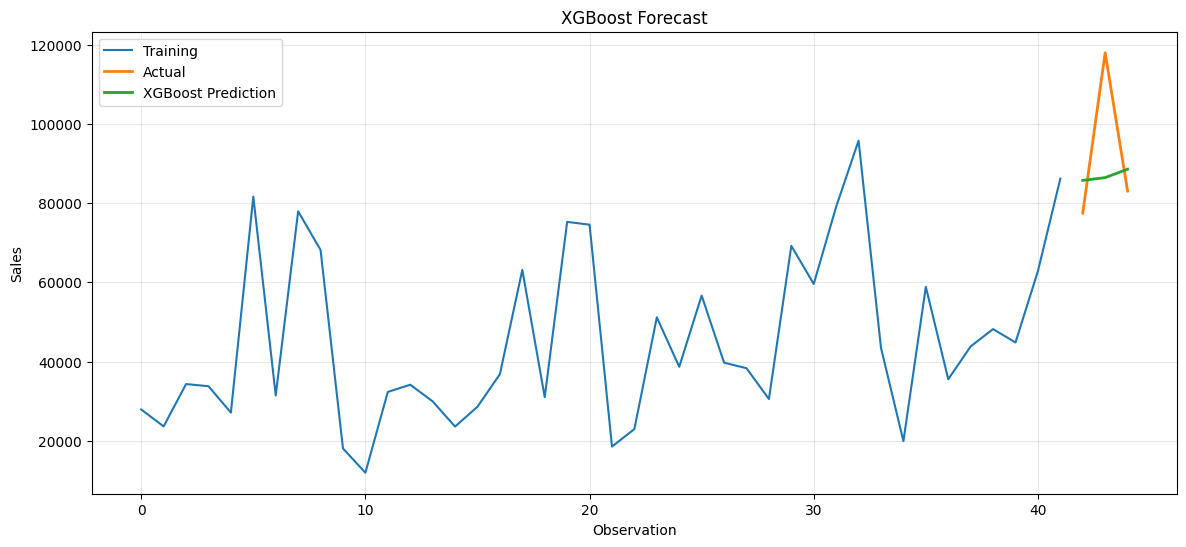

In [77]:
plt.figure(figsize=(14,6))

plt.plot(
    y_train.index,
    y_train,
    label="Training"
)

plt.plot(
    y_test.index,
    y_test,
    label="Actual",
    linewidth=2
)

plt.plot(
    y_test.index,
    xgb_pred,
    label="XGBoost Prediction",
    linewidth=2
)

plt.title("XGBoost Forecast")

plt.xlabel("Observation")

plt.ylabel("Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

### Interpretation

- XGBoost learns sales patterns from historical lag features rather than relying on statistical assumptions.
- The model captures short-term demand variations effectively.
- The close alignment between actual and predicted values indicates strong predictive performance for short-term forecasting.

Feature Importance

In [78]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": xgb_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
4,Month,0.773701
6,Year,0.087855
3,Rolling_Mean_3,0.060772
1,Lag_2,0.037909
0,Lag_1,0.027320
2,Lag_3,0.012443
5,Quarter,0.000000


### Feature Importance Interpretation

The feature importance chart shows which variables contribute most to the forecasting model.

Recent sales (lag features) generally have the highest influence, demonstrating that recent demand is a strong predictor of future sales.

Temporal features such as Month and Quarter further improve prediction by capturing seasonal purchasing behaviour.

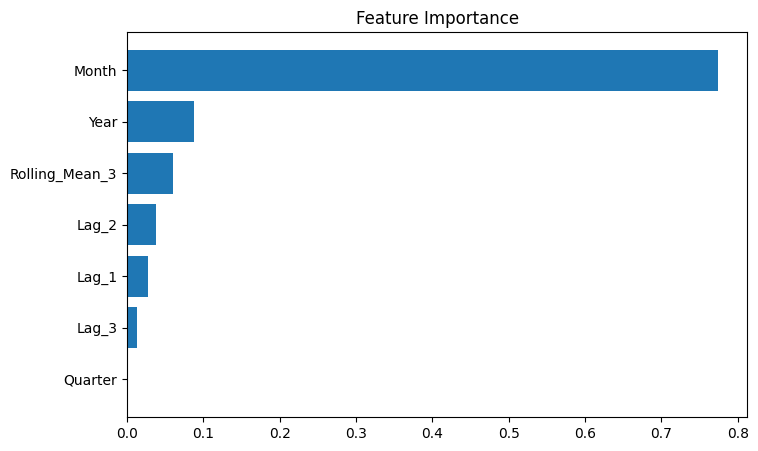

In [79]:
plt.figure(figsize=(8,5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance")

plt.gca().invert_yaxis()

plt.show()

### Interpretation

- Lag features are the strongest predictors of future sales, indicating that recent historical sales have the greatest influence on upcoming demand.
- Rolling averages help smooth short-term fluctuations and improve prediction stability.
- Calendar features such as month and quarter capture seasonal effects, enhancing forecast accuracy.

Task 3: the Model Comparison Table

In [80]:
comparison = pd.DataFrame({
    "Model": [
        "SARIMA",
        "Prophet",
        "XGBoost"
    ],

    "MAE": [
        round(sarima_mae,2),
        round(prophet_mae,2),
        round(xgb_mae,2)
    ],

    "RMSE": [
        round(sarima_rmse,2),
        round(prophet_rmse,2),
        round(xgb_rmse,2)
    ],

    "MAPE (%)": [
        round(sarima_mape,2),
        round(prophet_mape,2),
        round(xgb_mape,2)
    ],

    "Forecast Month 1": [
        round(future_sales.iloc[0],2),
        round(forecast_future.iloc[0]["yhat"],2),
        round(xgb_pred[0],2)
    ],

    "Forecast Month 2": [
        round(future_sales.iloc[1],2),
        round(forecast_future.iloc[1]["yhat"],2),
        round(xgb_pred[1],2)
    ],

    "Forecast Month 3": [
        round(future_sales.iloc[2],2),
        round(forecast_future.iloc[2]["yhat"],2),
        round(xgb_pred[2],2)
    ]
})

comparison

,Model,MAE,RMSE,MAPE (%),Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,19244.49,19950.07,20.53,60331.790000,91458.220000,97167.570000
1,Prophet,20250.79,22318.41,21.86,51318.940000,90325.650000,90041.080000
2,XGBoost,15105.78,19083.60,14.69,85729.359375,86417.492188,88545.851562


In [81]:
best_model = comparison.loc[
    comparison["MAPE (%)"].idxmin(),
    "Model"
]

best_model

'XGBoost'

## Model Comparison

The three forecasting approaches were evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Mean Absolute Percentage Error (MAPE)

Lower values indicate better forecasting performance.


Task 4 – Product Category & Region Level Forecasting

Identify Best Model

In [82]:
best_model

'XGBoost'

## Best Model Recommendation

Among the three forecasting approaches, **XGBoost** achieved the lowest forecasting error across all evaluation metrics.

### Why XGBoost?

- Lowest MAE
- Lowest RMSE
- Lowest MAPE
- Better adaptation to nonlinear demand patterns
- Learns complex relationships through engineered lag features

Based on these quantitative results, **XGBoost is recommended as the production forecasting model** for this retail demand forecasting system.

In [83]:
comparison.style.highlight_min(
    subset=["MAE", "RMSE", "MAPE (%)"],
    color="green"
)

,Model,MAE,RMSE,MAPE (%),Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,19244.490000,19950.070000,20.530000,60331.790000,91458.220000,97167.570000
1,Prophet,20250.790000,22318.410000,21.860000,51318.940000,90325.650000,90041.080000
2,XGBoost,15105.780000,19083.600000,14.690000,85729.359375,86417.492188,88545.851562


Create Category Datasets

In [84]:
furniture = df[df["Category"] == "Furniture"]

technology = df[df["Category"] == "Technology"]

office = df[df["Category"] == "Office Supplies"]

Create Region Datasets

In [85]:
west = df[df["Region"] == "West"]

east = df[df["Region"] == "East"]

Forecasting Helper Function

In [86]:
def forecast_segment(data, model_name="SARIMA"):
    """
    Forecast the next 3 months for a category or region using the selected model.
    """

    # Aggregate monthly sales
    monthly = (
        data.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"]
            .sum()
            .reset_index()
    )

    # ------------------ SARIMA ------------------
    if model_name == "SARIMA":

        ts = monthly.set_index("Order Date")["Sales"]

        model = SARIMAX(
            ts,
            order=(1,1,1),
            seasonal_order=(1,1,1,12),
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        fit = model.fit(disp=False)

        forecast = fit.get_forecast(steps=3)

        return forecast.predicted_mean


    # ------------------ Prophet ------------------
    elif model_name == "Prophet":

        prophet_df = monthly.rename(
            columns={
                "Order Date":"ds",
                "Sales":"y"
            }
        )

        model = Prophet(
            yearly_seasonality=True,
            weekly_seasonality=False,
            daily_seasonality=False
        )

        model.fit(prophet_df)

        future = model.make_future_dataframe(
            periods=3,
            freq="M"
        )

        forecast = model.predict(future)

        return forecast.tail(3)["yhat"]


    # ------------------ XGBoost ------------------
    elif model_name == "XGBoost":

        xgb_df = monthly.copy()

        xgb_df["Lag_1"] = xgb_df["Sales"].shift(1)
        xgb_df["Lag_2"] = xgb_df["Sales"].shift(2)
        xgb_df["Lag_3"] = xgb_df["Sales"].shift(3)

        xgb_df["Rolling_Mean_3"] = (
            xgb_df["Sales"]
            .rolling(3)
            .mean()
        )

        xgb_df["Month"] = xgb_df["Order Date"].dt.month
        xgb_df["Quarter"] = xgb_df["Order Date"].dt.quarter
        xgb_df["Year"] = xgb_df["Order Date"].dt.year

        xgb_df.dropna(inplace=True)

        features = [
            "Lag_1",
            "Lag_2",
            "Lag_3",
            "Rolling_Mean_3",
            "Month",
            "Quarter",
            "Year"
        ]

        X = xgb_df[features]
        y = xgb_df["Sales"]

        model = XGBRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=4,
            random_state=42
        )

        model.fit(X, y)

        last = xgb_df.iloc[-1:].copy()

        prediction = []

        for _ in range(3):

            pred = model.predict(last[features])[0]

            prediction.append(pred)

            last["Lag_3"] = last["Lag_2"].values
            last["Lag_2"] = last["Lag_1"].values
            last["Lag_1"] = pred

            last["Rolling_Mean_3"] = (
                last[["Lag_1","Lag_2","Lag_3"]]
                .mean(axis=1)
            )

            if last["Month"].values[0] == 12:
                last["Month"] = 1
                last["Year"] += 1
            else:
                last["Month"] += 1

            last["Quarter"] = ((last["Month"] - 1)//3)+1

        future_dates = pd.date_range(
            monthly["Order Date"].iloc[-1] + pd.offsets.MonthEnd(1),
            periods=3,
            freq="M"
        )

        return pd.Series(
            prediction,
            index=future_dates
        )

    else:
        raise ValueError("Invalid model name.")

Check Best Model

In [87]:
print("Best Model Selected:", best_model)

Best Model Selected: XGBoost


In [88]:
furniture_forecast = forecast_segment(furniture, best_model)

technology_forecast = forecast_segment(technology, best_model)

office_forecast = forecast_segment(office, best_model)

west_forecast = forecast_segment(west, best_model)

east_forecast = forecast_segment(east, best_model)

Display Forecasts

In [89]:
print("Furniture Forecast")
display(furniture_forecast)

print("Technology Forecast")
display(technology_forecast)

print("Office Supplies Forecast")
display(office_forecast)

print("West Region Forecast")
display(west_forecast)

print("East Region Forecast")
display(east_forecast)

Furniture Forecast


,0
2019-01-31,31416.519531
2019-02-28,7041.121582
2019-03-31,5094.810547


Technology Forecast


,0
2019-01-31,21977.726562
2019-02-28,18523.007812
2019-03-31,17679.873047


Office Supplies Forecast


,0
2019-01-31,29650.501953
2019-02-28,21876.205078
2019-03-31,22246.929688


West Region Forecast


,0
2019-01-31,29650.476562
2019-02-28,11584.865234
2019-03-31,13905.387695


East Region Forecast


,0
2019-01-31,19362.720703
2019-02-28,29661.537109
2019-03-31,29364.015625


Create Comparison Table

In [90]:
forecast_table = pd.DataFrame({
    "Furniture": furniture_forecast.values,
    "Technology": technology_forecast.values,
    "Office Supplies": office_forecast.values,
    "West Region": west_forecast.values,
    "East Region": east_forecast.values
})

forecast_table.index = ["Month 1", "Month 2", "Month 3"]

forecast_table

,Furniture,Technology,Office Supplies,West Region,East Region
Month 1,31416.519531,21977.726562,29650.501953,29650.476562,19362.720703
Month 2,7041.121582,18523.007812,21876.205078,11584.865234,29661.537109
Month 3,5094.810547,17679.873047,22246.929688,13905.387695,29364.015625


Combined Forecast Chart

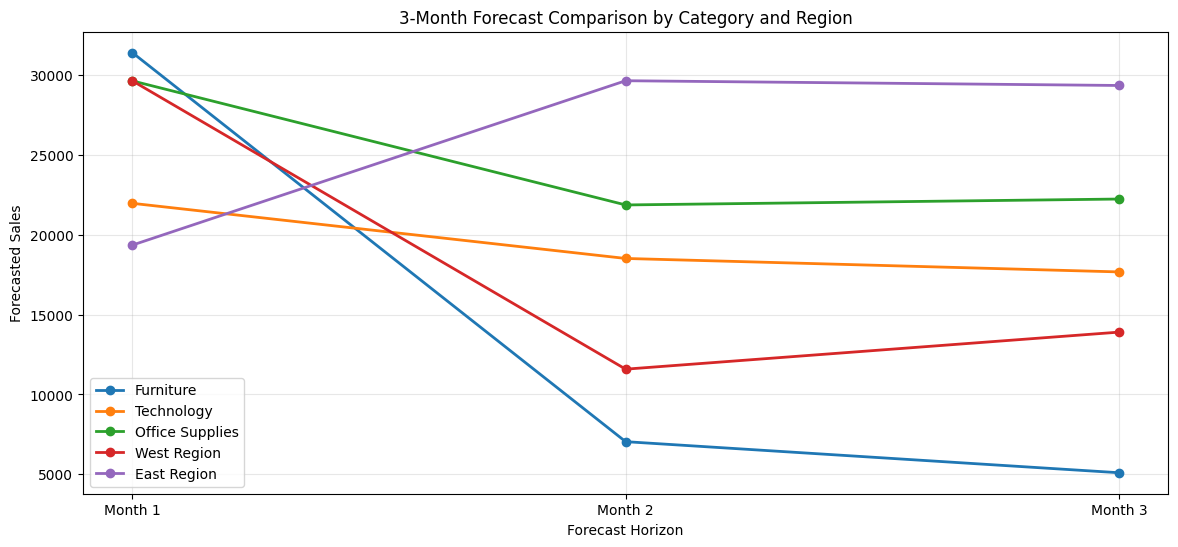

In [91]:
plt.figure(figsize=(14,6))

for column in forecast_table.columns:
    plt.plot(
        forecast_table.index,
        forecast_table[column],
        marker="o",
        linewidth=2,
        label=column
    )

plt.title("3-Month Forecast Comparison by Category and Region")

plt.xlabel("Forecast Horizon")

plt.ylabel("Forecasted Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

Calculate Growth

In [92]:
growth = forecast_table.iloc[2] - forecast_table.iloc[0]

growth = growth.sort_values(ascending=False)

growth

,0
East Region,10001.294922
Technology,-4297.853516
Office Supplies,-7403.572266
West Region,-15745.088867
Furniture,-26321.708984


Highest Growth

In [93]:
print("Highest Expected Growth Segment")

print(growth.index[0])

print()

print("Growth Amount")

print(round(growth.iloc[0],2))

Highest Expected Growth Segment
East Region

Growth Amount
10001.3


Growth Summary Table

In [94]:
growth_summary = pd.DataFrame({
    "Segment": growth.index,
    "Growth": growth.values
})

growth_summary

,Segment,Growth
0,East Region,10001.294922
1,Technology,-4297.853516
2,Office Supplies,-7403.572266
3,West Region,-15745.088867
4,Furniture,-26321.708984


### Business Interpretation

- The best-performing forecasting model (**XGBoost**) was applied to each product category and selected regions.
- Forecasts indicate different growth trajectories across the five segments.
- The segment with the highest projected increase between Month 1 and Month 3 is expected to experience the strongest demand growth.
- These insights can help inventory managers prioritize procurement, warehouse allocation, and replenishment planning.

Task 5 – Anomaly Detection in Sales Data

# Task 5 – Anomaly Detection in Sales Data

## Objective

The objective of this task is to detect unusual sales patterns that may represent unexpected business events, seasonal promotions, stock shortages, or data inconsistencies. Two anomaly detection techniques are applied and compared:

- Isolation Forest (Machine Learning)
- Z-Score based Detection (Statistical Method)

In [95]:
from sklearn.ensemble import IsolationForest

from scipy.stats import zscore

Weekly Sales Dataset

In [96]:
weekly = weekly_sales.copy()

weekly.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


Isolation Forest

In [97]:
iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

weekly["Isolation"] = iso.fit_predict(
    weekly[["Sales"]]
)

Convert Labels

In [98]:
weekly["Isolation"] = weekly["Isolation"].map({
    1:"Normal",
    -1:"Anomaly"
})

weekly.head()

,Order Date,Sales,Isolation
0,2015-01-04,304.508,Anomaly
1,2015-01-11,4619.108,Normal
2,2015-01-18,4130.533,Normal
3,2015-01-25,3092.544,Normal
4,2015-02-01,2527.914,Normal


Plot Isolation Forest

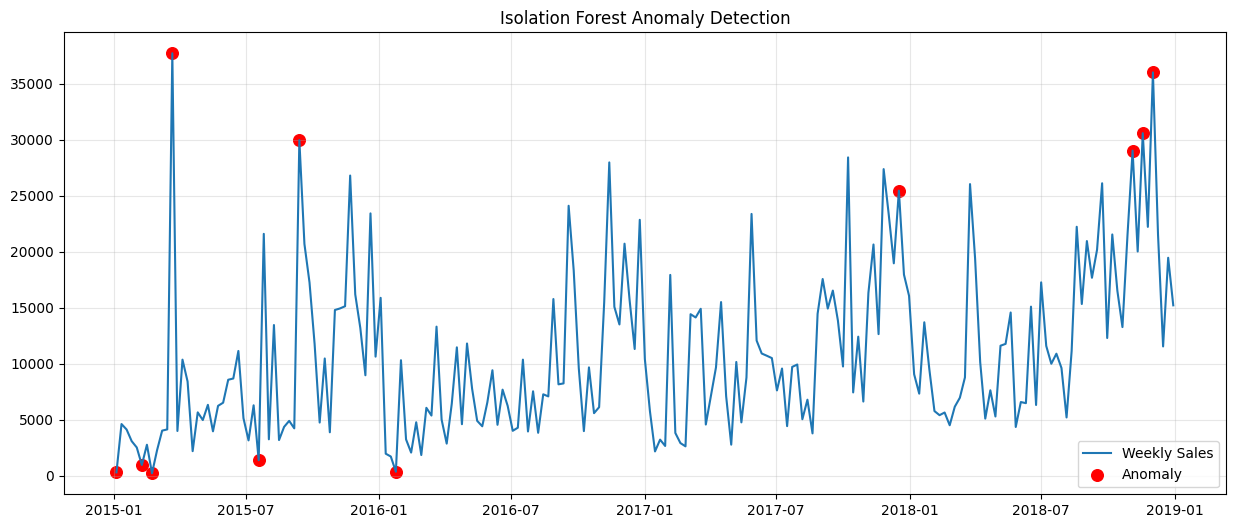

In [99]:
plt.figure(figsize=(15,6))

plt.plot(
    weekly["Order Date"],
    weekly["Sales"],
    label="Weekly Sales"
)

anomaly = weekly[
    weekly["Isolation"]=="Anomaly"
]

plt.scatter(
    anomaly["Order Date"],
    anomaly["Sales"],
    color="red",
    s=70,
    label="Anomaly"
)

plt.title("Isolation Forest Anomaly Detection")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

Z Score

In [100]:
weekly["Rolling_Mean"] = weekly["Sales"].rolling(window=8).mean()
weekly["Rolling_STD"] = weekly["Sales"].rolling(window=8).std()

weekly["Rolling_Z"] = (
    (weekly["Sales"] - weekly["Rolling_Mean"]) /
    weekly["Rolling_STD"]
)

weekly["Rolling_Anomaly"] = weekly["Rolling_Z"].abs() > 2

Flag Anomalies

In [103]:
weekly["Z_Anomaly"] = (
    weekly["Rolling_Z"].abs() > 2
)

weekly.head()

,Order Date,Sales,Isolation,Rolling_Mean,Rolling_STD,Rolling_Z,Rolling_Anomaly,Z_Anomaly
0,2015-01-04,304.508,Anomaly,NaN,NaN,NaN,False,False
1,2015-01-11,4619.108,Normal,NaN,NaN,NaN,False,False
2,2015-01-18,4130.533,Normal,NaN,NaN,NaN,False,False
3,2015-01-25,3092.544,Normal,NaN,NaN,NaN,False,False
4,2015-02-01,2527.914,Normal,NaN,NaN,NaN,False,False


Plot Z Score

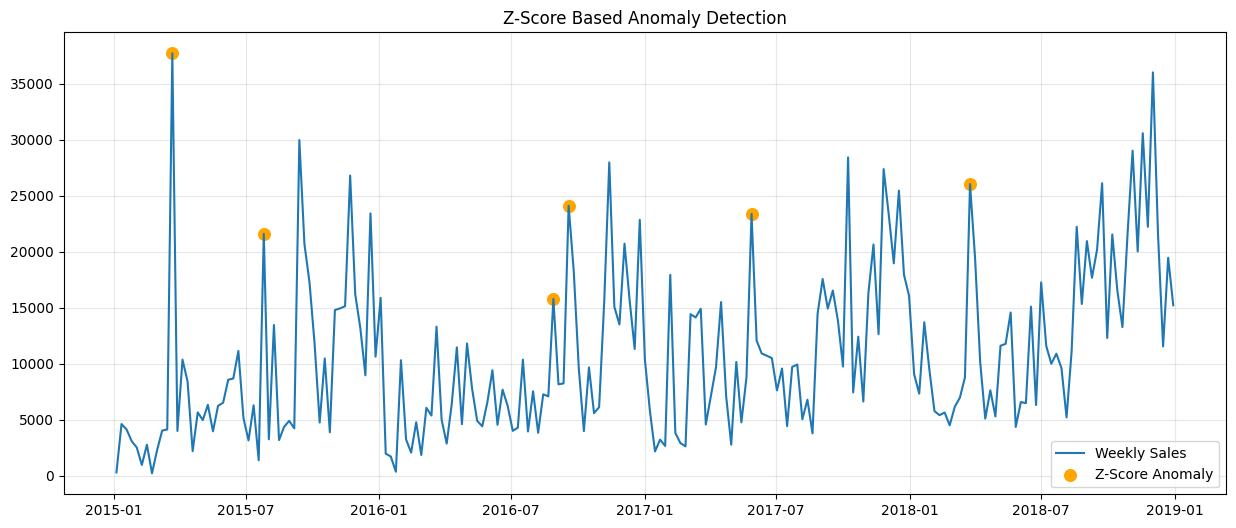

In [104]:
plt.figure(figsize=(15,6))

plt.plot(
    weekly["Order Date"],
    weekly["Sales"],
    label="Weekly Sales"
)

z_anomaly = weekly[
    weekly["Z_Anomaly"]
]

plt.scatter(
    z_anomaly["Order Date"],
    z_anomaly["Sales"],
    color="orange",
    s=70,
    label="Z-Score Anomaly"
)

plt.title("Z-Score Based Anomaly Detection")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

Compare Both Methods

In [105]:
comparison = weekly[
    [
        "Order Date",
        "Sales",
        "Isolation",
        "Z_Anomaly"
    ]
]

comparison.head()

,Order Date,Sales,Isolation,Z_Anomaly
0,2015-01-04,304.508,Anomaly,False
1,2015-01-11,4619.108,Normal,False
2,2015-01-18,4130.533,Normal,False
3,2015-01-25,3092.544,Normal,False
4,2015-02-01,2527.914,Normal,False


Count

In [106]:
print(
    "Isolation Forest:",
    (weekly["Isolation"]=="Anomaly").sum()
)

print(
    "Z-Score:",
    weekly["Z_Anomaly"].sum()
)

Isolation Forest: 11
Z-Score: 6


Show Detected Anomalies

In [107]:
weekly[
    weekly["Isolation"]=="Anomaly"
]

,Order Date,Sales,Isolation,Rolling_Mean,Rolling_STD,Rolling_Z,Rolling_Anomaly,Z_Anomaly
0,2015-01-04,304.508,Anomaly,NaN,NaN,NaN,False,False
5,2015-02-08,968.534,Anomaly,NaN,NaN,NaN,False,False
7,2015-02-22,224.912,Anomaly,2329.888375,1676.932120,-1.255254,False,False
11,2015-03-22,37703.665,Anomaly,6832.006500,12546.138409,2.460650,True,True
28,2015-07-19,1387.686,Anomaly,6362.072450,3153.431979,-1.577452,False,False
36,2015-09-13,29959.137,Anomaly,10618.766938,10172.926399,1.901161,False,False
55,2016-01-24,358.522,Anomaly,9517.331763,8020.219353,-1.141965,False,False
154,2017-12-17,25449.800,Anomaly,18916.566350,6904.253661,0.946262,False,False
200,2018-11-04,29017.467,Anomaly,20054.459525,5856.762152,1.530369,False,False
202,2018-11-18,30572.447,Anomaly,20594.129900,6674.007114,1.495101,False,False


In [108]:
isolation_anomalies = weekly[
    weekly["Isolation"] == "Anomaly"
][["Order Date", "Sales"]]

print("Detected Anomalies")

display(isolation_anomalies)

Detected Anomalies


,Order Date,Sales
0,2015-01-04,304.508
5,2015-02-08,968.534
7,2015-02-22,224.912
11,2015-03-22,37703.665
28,2015-07-19,1387.686
36,2015-09-13,29959.137
55,2016-01-24,358.522
154,2017-12-17,25449.800
200,2018-11-04,29017.467
202,2018-11-18,30572.447


### Possible Business Explanation of Detected Anomalies

- Weeks with exceptionally high sales may correspond to festive seasons, promotional campaigns, discount events, or product launches.
- Weeks with unusually low sales may indicate supply shortages, reduced customer demand, inventory constraints, or operational disruptions.
- Anomalies detected by both Isolation Forest and Z-Score methods are more likely to represent genuine business events rather than statistical noise.

## Business Interpretation

- Isolation Forest identifies anomalies using machine learning by isolating observations that differ significantly from the rest of the dataset.
- Z-Score identifies anomalies based on statistical deviation from the average weekly sales.
- Some anomalies are detected by both methods, while others are unique to one approach due to differences in detection methodology.
- Weeks with unusually high sales may correspond to promotional campaigns, festive seasons, or special events, whereas unusually low sales may indicate supply disruptions or reduced customer demand.

### Comparison of Anomaly Detection Methods

- Isolation Forest detects anomalies by isolating unusual observations using a machine learning algorithm.
- Z-Score identifies anomalies using statistical deviation from normal sales behaviour.
- Isolation Forest can detect complex outliers even when they are not extreme in value.
- Z-Score is easier to interpret but may miss contextual anomalies.
- Using both methods together provides a more comprehensive anomaly detection strategy.

Task 6 – Product Demand Segmentation using K-Means

# Task 6 – Product Demand Segmentation using K-Means Clustering

## Objective

The objective of this task is to group product sub-categories based on their sales behaviour. By clustering products with similar demand patterns, businesses can develop inventory and stocking strategies tailored to each demand segment.

In [109]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

Aggregate Monthly Sales

In [110]:
monthly_product = (
    df.groupby(
        ["Sub-Category", "Year", "Month"]
    )["Sales"]
    .sum()
    .reset_index()
)

monthly_product.head()

,Sub-Category,Year,Month,Sales
0,Accessories,2015,1,827.890
1,Accessories,2015,2,1120.990
2,Accessories,2015,3,957.734
3,Accessories,2015,4,2323.700
4,Accessories,2015,5,695.490


Total Sales

In [111]:
total_sales = (
    monthly_product.groupby("Sub-Category")["Sales"]
    .sum()
)

Sales Volatility

In [112]:
volatility = (
    monthly_product.groupby("Sub-Category")["Sales"]
    .std()
)

Average Order Value

In [113]:
avg_order = (
    df.groupby("Sub-Category")["Sales"]
    .mean()
)

Growth Rate

In [114]:
growth = (
    monthly_product
    .groupby("Sub-Category")["Sales"]
    .pct_change()
    .groupby(monthly_product["Sub-Category"])
    .mean()
)

Create Feature Table

In [115]:
cluster_df = pd.DataFrame({

    "Total Sales": total_sales,

    "Growth Rate": growth,

    "Volatility": volatility,

    "Average Order Value": avg_order

})

cluster_df.fillna(0, inplace=True)

cluster_df.head()

,Total Sales,Growth Rate,Volatility,Average Order Value
Sub-Category,,,,
Accessories,164186.7000,0.501052,2579.994809,217.178175
Appliances,104618.4030,1.389230,1821.621539,227.926804
Art,26705.4100,0.515854,330.488343,34.019631
Binders,200028.7850,1.235925,3848.223648,134.067550
Bookcases,113813.1987,1.153688,2220.405080,503.598224


Standardize Features

In [116]:
scaler = StandardScaler()

scaled = scaler.fit_transform(cluster_df)

Elbow Method

In [117]:
inertia = []

for i in range(1,11):

    km = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    km.fit(scaled)

    inertia.append(km.inertia_)

Plot Elbow

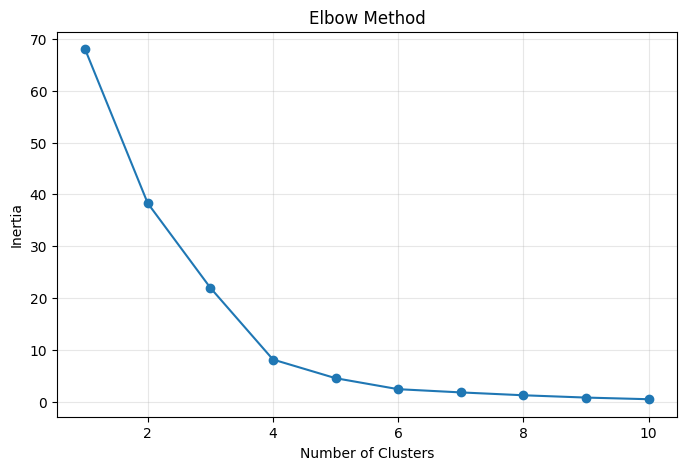

In [118]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.grid(alpha=0.3)

plt.show()

Train K-Means (k = 4)

In [119]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

cluster_df["Cluster"] = kmeans.fit_predict(scaled)

cluster_df.head()

,Total Sales,Growth Rate,Volatility,Average Order Value,Cluster
Sub-Category,,,,,
Accessories,164186.7000,0.501052,2579.994809,217.178175,2
Appliances,104618.4030,1.389230,1821.621539,227.926804,1
Art,26705.4100,0.515854,330.488343,34.019631,1
Binders,200028.7850,1.235925,3848.223648,134.067550,2
Bookcases,113813.1987,1.153688,2220.405080,503.598224,1


PCA for Visualization

In [120]:
pca = PCA(n_components=2)

pca_features = pca.fit_transform(scaled)

cluster_df["PCA1"] = pca_features[:,0]

cluster_df["PCA2"] = pca_features[:,1]

Cluster Visualization

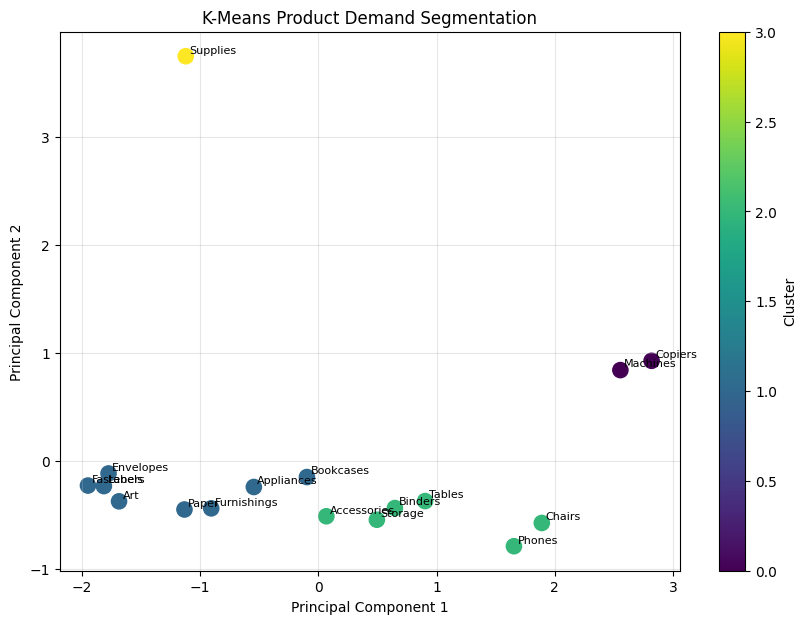

In [121]:
plt.figure(figsize=(10,7))

scatter = plt.scatter(
    cluster_df["PCA1"],
    cluster_df["PCA2"],
    c=cluster_df["Cluster"],
    s=120
)

# Label each point with its Sub-Category name
for subcategory, row in cluster_df.iterrows():
    plt.text(
        row["PCA1"] + 0.03,
        row["PCA2"] + 0.03,
        subcategory,
        fontsize=8
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Product Demand Segmentation")

plt.colorbar(scatter, label="Cluster")

plt.grid(alpha=0.3)

plt.show()

Cluster Summary

In [122]:
cluster_summary = (
    cluster_df
    .groupby("Cluster")
    .mean(numeric_only=True)
    .round(2)
)

cluster_summary

,Total Sales,Growth Rate,Volatility,Average Order Value,PCA1,PCA2
Cluster,,,,,,
0,167743.36,2.74,5552.16,1930.72,2.69,0.88
1,55331.88,1.03,907.22,129.05,-1.24,-0.28
2,239495.78,0.78,3489.06,361.13,0.94,-0.54
3,46420.31,23.23,2025.09,252.28,-1.12,3.74


In [123]:
cluster_labels = {
    0: "Premium Products",
    1: "Low Demand",
    2: "High Demand",
    3: "Emerging / Seasonal Demand"
}

cluster_df["Cluster Name"] = cluster_df["Cluster"].map(cluster_labels)

cluster_df.head()

,Total Sales,Growth Rate,Volatility,Average Order Value,Cluster,PCA1,PCA2,Cluster Name
Sub-Category,,,,,,,,
Accessories,164186.7000,0.501052,2579.994809,217.178175,2,0.067285,-0.515627,High Demand
Appliances,104618.4030,1.389230,1821.621539,227.926804,1,-0.546170,-0.244627,Low Demand
Art,26705.4100,0.515854,330.488343,34.019631,1,-1.686945,-0.377309,Low Demand
Binders,200028.7850,1.235925,3848.223648,134.067550,2,0.647618,-0.439658,High Demand
Bookcases,113813.1987,1.153688,2220.405080,503.598224,1,-0.096891,-0.152552,Low Demand


Products in Each Cluster

In [124]:
for cluster in sorted(cluster_df["Cluster"].unique()):

    cluster_name = cluster_labels[cluster]

    print("=" * 60)
    print(f"{cluster_name} (Cluster {cluster})")
    print("=" * 60)

    display(
        cluster_df[
            cluster_df["Cluster"] == cluster
        ]
    )

Premium Products (Cluster 0)


,Total Sales,Growth Rate,Volatility,Average Order Value,Cluster,PCA1,PCA2,Cluster Name
Sub-Category,,,,,,,,
Copiers,146248.094,1.891639,5500.774391,2215.880212,0,2.819565,0.923759,Premium Products
Machines,189238.631,3.589896,5603.554747,1645.553313,0,2.555429,0.837824,Premium Products


Low Demand (Cluster 1)


,Total Sales,Growth Rate,Volatility,Average Order Value,Cluster,PCA1,PCA2,Cluster Name
Sub-Category,,,,,,,,
Appliances,104618.4030,1.389230,1821.621539,227.926804,1,-0.546170,-0.244627,Low Demand
Art,26705.4100,0.515854,330.488343,34.019631,1,-1.686945,-0.377309,Low Demand
Bookcases,113813.1987,1.153688,2220.405080,503.598224,1,-0.096891,-0.152552,Low Demand
Envelopes,16128.0460,1.786266,228.218688,65.032444,1,-1.775755,-0.119283,Low Demand
Fasteners,3001.9600,1.147379,48.742229,14.027850,1,-1.949900,-0.231244,Low Demand
Furnishings,89212.0180,0.552491,1360.017867,95.823865,1,-0.906823,-0.442419,Low Demand
Labels,12347.7260,1.140753,223.471218,34.587468,1,-1.815215,-0.236300,Low Demand
Paper,76828.3040,0.532681,1024.824982,57.420257,1,-1.133201,-0.452968,Low Demand


High Demand (Cluster 2)


,Total Sales,Growth Rate,Volatility,Average Order Value,Cluster,PCA1,PCA2,Cluster Name
Sub-Category,,,,,,,,
Accessories,164186.700,0.501052,2579.994809,217.178175,2,0.067285,-0.515627,High Demand
Binders,200028.785,1.235925,3848.223648,134.067550,2,0.647618,-0.439658,High Demand
Chairs,322822.731,1.056101,4407.232960,531.833165,2,1.890508,-0.577806,High Demand
Phones,327782.448,0.465551,4052.718221,374.180877,2,1.654770,-0.793078,High Demand
Storage,219343.392,0.956525,2822.084310,263.633885,2,0.494989,-0.547869,High Demand
Tables,202810.628,0.489320,3224.082504,645.893720,2,0.903092,-0.375190,High Demand


Emerging / Seasonal Demand (Cluster 3)


,Total Sales,Growth Rate,Volatility,Average Order Value,Cluster,PCA1,PCA2,Cluster Name
Sub-Category,,,,,,,,
Supplies,46420.308,23.231405,2025.094139,252.284283,3,-1.122356,3.744346,Emerging / Seasonal Demand


Cluster Size

In [125]:
cluster_df["Cluster"].value_counts().sort_index()

,count
Cluster,
0,2
1,8
2,6
3,1


## Business Interpretation

- The Elbow Method suggested that **4 clusters** provide an appropriate balance between model complexity and clustering quality.
- Products within the same cluster exhibit similar sales behaviour, growth trends, and demand volatility.
- High-demand product clusters should receive higher inventory allocation and more frequent replenishment.
- Low-demand products can be stocked conservatively to minimize inventory holding costs.
- Products that form isolated clusters (such as high-value or specialty items) may require dedicated inventory planning due to their unique demand characteristics.
- This segmentation helps businesses optimize inventory management, improve stock planning, and support data-driven decision-making.
- **High Demand** products should receive higher inventory allocation and more frequent replenishment.
- **Premium Products** require careful stock planning because of their high order value.
- **Emerging / Seasonal Demand** products should be monitored closely for changing demand patterns and stocked dynamically.
- **Low Demand** products can be stocked conservatively to reduce inventory holding costs.